In [1]:
#Loading Libraries
from pyspark.sql import SparkSession

from pyspark.ml.feature import (VectorAssembler,
    StringIndexer)

from pyspark.ml.classification  import(
    DecisionTreeClassifier,
    RandomForestClassifier
)
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import  (
    confusion_matrix, 
    classification_report,
    ConfusionMatrixDisplay
)
print("All Libraries Loaded Successfully")


All Libraries Loaded Successfully


In [2]:
#creating Spark Session
spark =  SparkSession.builder.appName('Income Spark Classification').getOrCreate()
print("Spark Session Created Successfully")

Spark Session Created Successfully


In [3]:
#Loding the Dataset
df = spark.read.csv(r"c:\Users\2539990\Downloads\income.csv", header=True, inferSchema=True)
print('Rows: ', df.count())
print('Columns: ', len(df.columns))
df.show(5)

Rows:  32561
Columns:  15
+---+-----------------+--------+----------+---------------+-------------------+------------------+--------------+------+-------+------------+------------+--------------+--------------+------------+
|age|        workclass|  weight| education|education_years|     marital_status|        occupation|  relationship|  race|    sex|capital_gain|capital_loss|hours_per_week|   citizenship|income_class|
+---+-----------------+--------+----------+---------------+-------------------+------------------+--------------+------+-------+------------+------------+--------------+--------------+------------+
| 39|        State-gov| 77516.0| Bachelors|           13.0|      Never-married|      Adm-clerical| Not-in-family| White|   Male|      2174.0|         0.0|          40.0| United-States|       <=50K|
| 50| Self-emp-not-inc| 83311.0| Bachelors|           13.0| Married-civ-spouse|   Exec-managerial|       Husband| White|   Male|         0.0|         0.0|          13.0| United-State

In [4]:
#Exploratory Data Analysis
pandas_df = df.toPandas() #Converting Spark DataFrame to Pandas DataFrame for EDA
print("DataFrame converted to Pandas DataFrame for EDA")
pandas_df.head()

DataFrame converted to Pandas DataFrame for EDA


,age,workclass,weight,education,education_years,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,citizenship,income_class
0,39,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K
1,50,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,<=50K
2,38,Private,215646.0,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
3,53,Private,234721.0,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K
4,28,Private,338409.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K


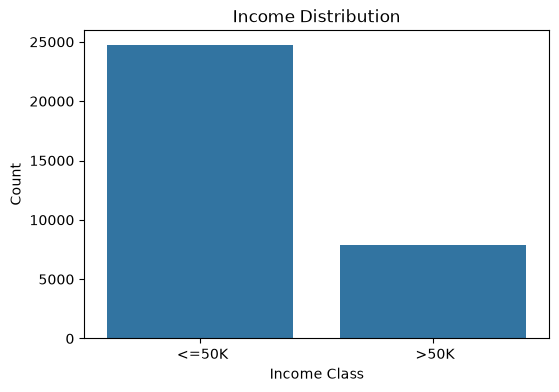

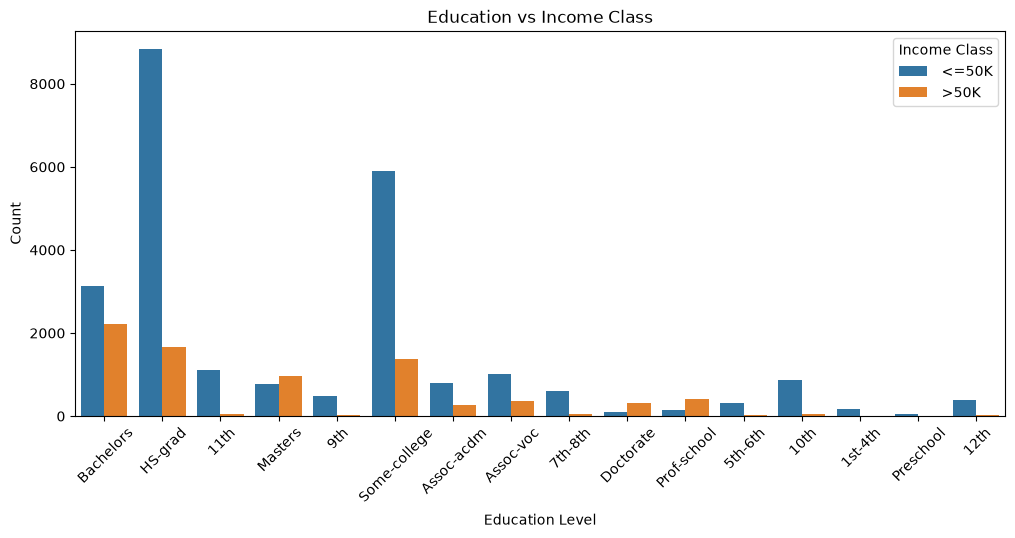

In [5]:
# Visualization of income distribution
plt.figure(figsize=(6,4))
sns.countplot(x='income_class', data=pandas_df)
plt.title('Income Distribution')
plt.xlabel('Income Class')
plt.ylabel('Count')
plt.show()

# Visualization of education vs income class
plt.figure(figsize=(12,5))
sns.countplot(x='education', hue='income_class', data=pandas_df)
plt.xticks(rotation=45)
plt.title('Education vs Income Class')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.legend(title='Income Class')
plt.show()


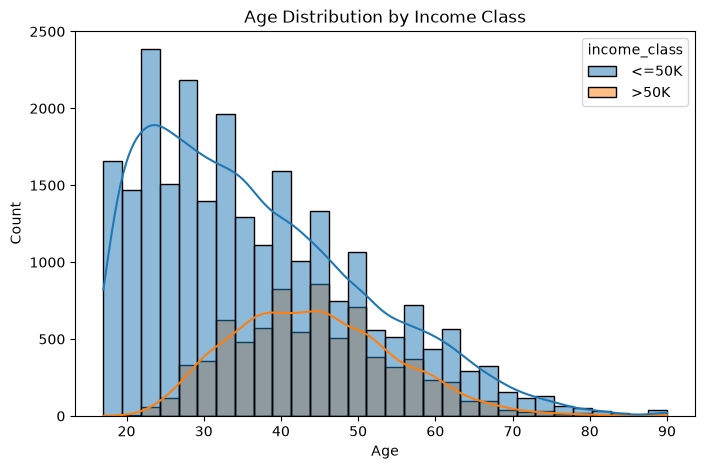

In [6]:
# Visualizing age distribution by income class
plt.figure(figsize=(8,5))
sns.histplot(data=pandas_df, x='age', hue='income_class', bins=30, kde=True)
plt.title('Age Distribution by Income Class')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

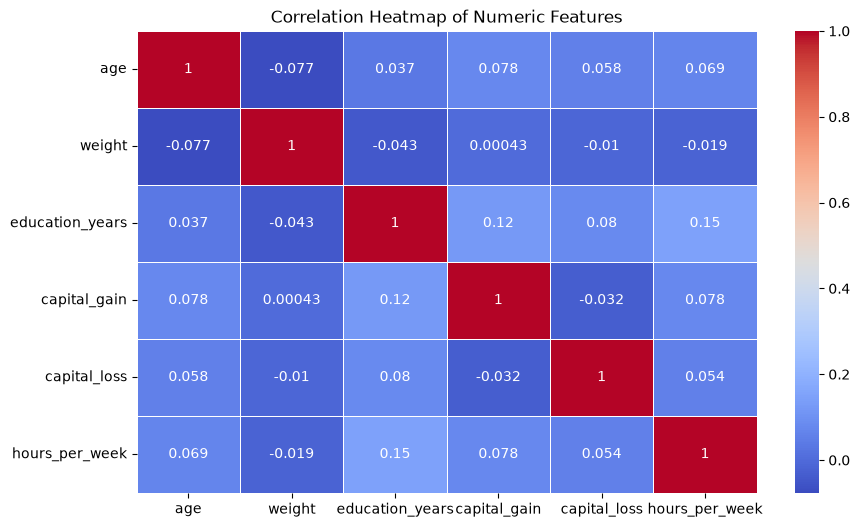

In [7]:
#Correlation Heatmap 
numeric_cols = ['age','weight','education_years','capital_gain','capital_loss','hours_per_week']
plt.figure(figsize=(10,6))
sns.heatmap(pandas_df[numeric_cols].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

In [8]:
#Data Preprocessing and Feature Engineering
#String Indexing for categorical features
label_indexer = StringIndexer(inputCol='income_class', outputCol='label')

#List of categorical columns to be indexed
categorical_cols = ["workclass","education","marital_status","occupation","relationship","race","sex","citizenship"]

#Creating StringIndexers for each categorical column
indexers = [
    StringIndexer(
        inputCol=col,
        outputCol=col + "_index",
        handleInvalid="keep"
    )
    for col in categorical_cols
]
print("String Indexers Created for Categorical Columns")

String Indexers Created for Categorical Columns


In [9]:
#Feature columns for the model
feature_cols = ['age', 'weight', 'education_years', 'capital_gain', 'capital_loss', 'hours_per_week'] + [col+"_index" for col in categorical_cols]
print("Feature Columns Prepared for Model Training")
print(feature_cols)

Feature Columns Prepared for Model Training
['age', 'weight', 'education_years', 'capital_gain', 'capital_loss', 'hours_per_week', 'workclass_index', 'education_index', 'marital_status_index', 'occupation_index', 'relationship_index', 'race_index', 'sex_index', 'citizenship_index']


In [10]:
# Vector Assembler to combine feature columns into a single feature vector
assembler = VectorAssembler(inputCols=feature_cols, outputCol='features')
print("Vector Assembler Created to Combine Feature Columns")
print(assembler)

Vector Assembler Created to Combine Feature Columns
VectorAssembler_7c8a0ec3d82f


In [11]:
#train-test split
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)
print('Training Rows: ', train_df.count())
print('Testing Rows: ', test_df.count())
print("Train-Test Split Completed Successfully")


Training Rows:  26076
Testing Rows:  6485
Train-Test Split Completed Successfully


In [12]:
# Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(labelCol='label', featuresCol='features', maxBins =50)
dt_pipeline = Pipeline(stages=indexers + [label_indexer, assembler, dt_classifier])
dt_model = dt_pipeline.fit(train_df)
dt_predictions = dt_model.transform(test_df)
print("Decision Tree Model Trained and Predictions Made on Test Set")


Decision Tree Model Trained and Predictions Made on Test Set


In [13]:
# # Evaluation of Decision Tree Model Accuracy
dt = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="label", 
    maxBins = 50

)

dt_pipeline = Pipeline(
    stages=[label_indexer] + indexers + [assembler, dt]
)

dt_model = dt_pipeline.fit(train_df)

dt_predictions = dt_model.transform(test_df)
print("Evaluation of Decision Tree Model Accuracy Completed")


Evaluation of Decision Tree Model Accuracy Completed


In [14]:
# Classification report 
dt_pd = dt_predictions.select(
    "label",
    "prediction"
).toPandas()

print(
    classification_report(
        dt_pd["label"],
        dt_pd["prediction"]
    )
)

              precision    recall  f1-score   support

         0.0       0.86      0.94      0.90      4908
         1.0       0.74      0.53      0.62      1577

    accuracy                           0.84      6485
   macro avg       0.80      0.74      0.76      6485
weighted avg       0.83      0.84      0.83      6485



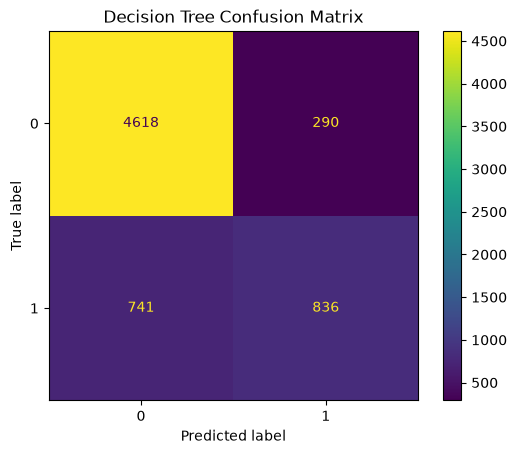

In [15]:
# Confusion Matrix for Decision Tree Model
cm = confusion_matrix(
    dt_pd["label"],
    dt_pd["prediction"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    "Decision Tree Confusion Matrix"
)

plt.show()

In [16]:
# Random Forest Classifier
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=100,
    seed=42,
    maxBins=50)

rf_pipeline = Pipeline(
    stages=[
        label_indexer,
        *indexers,
        assembler,
        rf])

rf_model = rf_pipeline.fit(train_df)

rf_predictions = rf_model.transform(test_df)
print('Random forest classifier model trained and predictions made on test set')

Random forest classifier model trained and predictions made on test set


In [17]:
# Evaluation of Random Forest Model Accuracy
evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)
rf_accuracy = evaluator.evaluate(
    rf_predictions
)

print(
    "Random Forest Accuracy:",
    rf_accuracy
)


rf_pd = rf_predictions.select(
    "label",
    "prediction"
).toPandas()

print(
    classification_report(
        rf_pd["label"],
        rf_pd["prediction"]
    )
)

Random Forest Accuracy: 0.8450269853508096
              precision    recall  f1-score   support

         0.0       0.85      0.96      0.90      4908
         1.0       0.80      0.49      0.61      1577

    accuracy                           0.85      6485
   macro avg       0.82      0.72      0.75      6485
weighted avg       0.84      0.85      0.83      6485



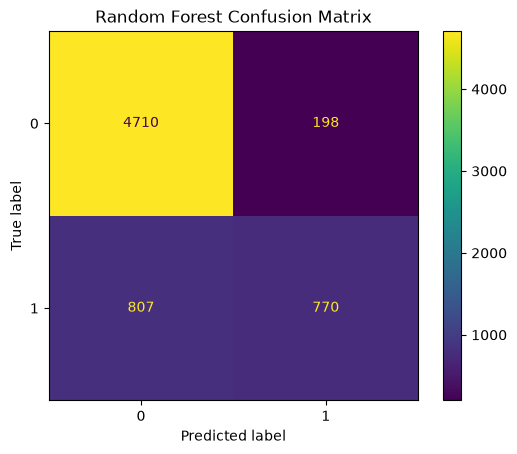

In [18]:
# Confusion Matrix for Random Forest Model
cm = confusion_matrix(
    rf_pd["label"],
    rf_pd["prediction"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    "Random Forest Confusion Matrix"
)

plt.show()

In [19]:
# feature importance 
rf_stage = rf_model.stages[-1]

importances = (
    rf_stage.featureImportances
            .toArray()
)

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
8,marital_status_index,0.262778
3,capital_gain,0.201240
10,relationship_index,0.187350
2,education_years,0.127647
9,occupation_index,0.095269
0,age,0.040646
5,hours_per_week,0.024525
4,capital_loss,0.023443
7,education_index,0.023339
12,sex_index,0.010079


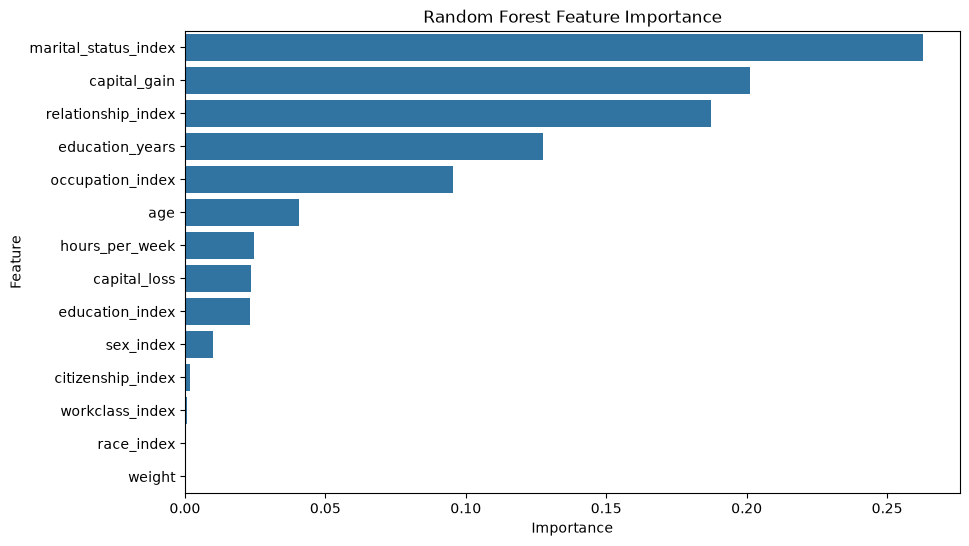

In [20]:
# Visualizing Feature Importance
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.show()

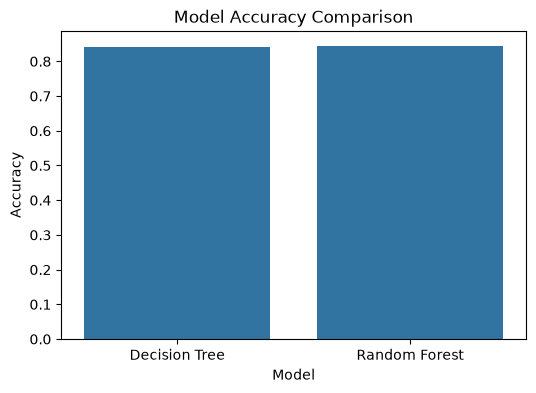

,Model,Accuracy
0,Decision Tree,0.841018
1,Random Forest,0.845027


In [21]:
# comparing the accuracy of Decision Tree and Random Forest models using visualization
dt_accuracy = evaluator.evaluate(
    dt_predictions
)
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        dt_accuracy,
        rf_accuracy
    ]
})

plt.figure(figsize=(6,4))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy")

plt.title(
    "Model Accuracy Comparison")
plt.show()
comparison

In [22]:
# comparing the accuracy of Decision Tree and Random Forest models
print(f"Decision Tree Accuracy : {dt_accuracy * 100:.4f}%")
print(f"Random Forest Accuracy : {rf_accuracy * 100:.4f}%")

if rf_accuracy > dt_accuracy:
    print(
        "\nRandom Forest performed better than the Decision Tree classifier."
    )

Decision Tree Accuracy : 84.1018%
Random Forest Accuracy : 84.5027%

Random Forest performed better than the Decision Tree classifier.


# Key Findings

* Random Forest outperformed the Decision Tree classifier.
* The final model achieved an accuracy above 80%.
* Age, education years, capital gain, and hours worked per week were among the most important predictive features.
* Individuals with higher education levels and greater capital gains were more likely to belong to the >$50K income group.
* Spark MLlib successfully handled data preprocessing, feature engineering, model training, and evaluation within a distributed computing environment.
